# Question 3

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import norm
from scipy.optimize import minimize

In [2]:
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
plt.close("all")

alpha = 0.95
save_figures = True

img_dir = "Images"
out_dir = "Results"

os.makedirs(img_dir, exist_ok=True)
os.makedirs(out_dir, exist_ok=True)

In [3]:
# ============================================================
# 1. LOAD DATA AND COMPUTE LOG RETURNS
# ============================================================

df_prices   = pd.read_excel('E:/Bayes FM MSc/Term 2/Risk Analysis/Coursework/price_data.xlsx')
df_prices = df_prices.dropna(axis=0)

dates = pd.to_datetime(df_prices.iloc[:, 0])
tickers = df_prices.columns[1:].tolist()
prices = df_prices.iloc[:, 1:].astype(float).values

n_obs, n_assets = prices.shape

# Daily log returns
log_ret = np.log(prices[1:, :] / prices[:-1, :])

# Split sample into first half / second half
split_idx = log_ret.shape[0] // 2
ret_train = log_ret[:split_idx, :]
ret_test = log_ret[split_idx:, :]

test_dates = dates.iloc[split_idx + 1:].reset_index(drop=True)

print("Tickers:", tickers)
print("Number of price observations:", n_obs)
print("Training return observations:", ret_train.shape[0])
print("Test return observations:", ret_test.shape[0])

Tickers: ['AAPL', 'MSFT', 'IBM', 'NVDA', 'GOOGL', 'AMZN']
Number of price observations: 2998
Training return observations: 1498
Test return observations: 1499


In [4]:
# ============================================================
# 2. Risk Measures functions
# ============================================================

def get_riskmeasures(model, x, conf_level):
    """
    Similar to professor's get_riskmeasures.m

    model = 'G'   -> Gaussian VaR
    model = 'NP'  -> non-parametric / historical VaR
    """
    x = np.asarray(x).reshape(-1)

    if model == 'G':
        mu_x = np.mean(x)
        std_x = np.std(x, ddof=1)
        z = norm.ppf(1 - conf_level)
        var_ = -(mu_x + z * std_x)
        return var_

    elif model == 'NP':
        var_ = -np.quantile(x, 1 - conf_level)
        return var_

    else:
        raise ValueError("model must be 'G', or 'NP'")

In [5]:
# ============================================================
# 3. Hot-spot Functions
# ============================================================
# ------------------------------------------------------------
# PARAMETRIC COMPONENT VaR (Gaussian)
# Based on:
# VaR = -w'μ - z * sqrt(w'Σw)
# MVaR = -μ - z * Σw / sqrt(w'Σw)
# CVaR = w .* MVaR
# ------------------------------------------------------------
def gaussian_hotspot(weights, mu, sigma, alpha):
    """
    Gaussian Hot Spot:
    returns portfolio VaR, MVaR, CVaR
    """
    weights = np.asarray(weights).reshape(-1)
    mu = np.asarray(mu).reshape(-1)

    mu_p = weights @ mu
    sigma_p = np.sqrt(weights.T @ sigma @ weights)

    z = norm.ppf(1 - alpha)

    var_p = -(mu_p + z * sigma_p)
    mvar = -(mu + z * (sigma @ weights) / sigma_p)
    cvar = weights * mvar

    return var_p, mvar, cvar

# ------------------------------------------------------------
# NON-PARAMETRIC COMPONENT VaR
# Approximation:
# MVaR_i ≈ -E[r_i | r_p ≈ -VaR]
# ------------------------------------------------------------

def nonparam_hotspot(weights, ret_matrix, alpha, epsilon=0.001):
    """
    Non-parametric Hot Spot:
    returns portfolio VaR, MVaR, CVaR
    """
    weights = np.asarray(weights).reshape(-1)
    rp = ret_matrix @ weights

    var_p = get_riskmeasures('NP', rp, alpha)

    # Marginal VaR via small window around -VaR
    var_return = -var_p
    idx_var = np.where(np.abs(rp - var_return) < epsilon)[0]

    # fallback: nearest observations if too few in the window
    if len(idx_var) < 10:
        order = np.argsort(np.abs(rp - var_return))
        k = min(30, len(order))
        idx_var = order[:k]

    mvar = -np.mean(ret_matrix[idx_var, :], axis=0)
    cvar = weights * mvar

    return var_p, mvar, cvar

In [6]:
# ============================================================
# 4. Objective functions
# ============================================================
def obj_risk_parity_gaussian(weights, mu, sigma, alpha):
    """
    Minimize dispersion of Gaussian component VaRs
    """
    _, _, cvar = gaussian_hotspot(weights, mu, sigma, alpha)
    return np.std(cvar)


def obj_risk_parity_nonparam(weights, ret_matrix, alpha):
    """
    Minimize dispersion of non-parametric component VaRs
    """
    _, _, cvar = nonparam_hotspot(weights, ret_matrix, alpha)
    return np.std(cvar)


def obj_max_div(weights, sigma):
    """
    Maximum diversification:
    maximize (w' sigma_i) / sqrt(w' Sigma w)
    """
    weights = np.asarray(weights).reshape(-1)
    indiv_vol = np.sqrt(np.diag(sigma))
    port_vol = np.sqrt(weights.T @ sigma @ weights)
    div_ratio = (weights @ indiv_vol) / port_vol
    return -div_ratio



In [7]:
# ============================================================
# 5. In-sample portfolio weights
# ============================================================

# In-sample moments
mu = np.mean(ret_train, axis=0)
sigma = np.cov(ret_train, rowvar=False)

# Portfolio constraints
bounds = tuple((0,1.0) for x in range(n_assets))
constraints = [{"type": "eq", "fun": lambda w: np.sum(w) - 1.0}]
w0 = np.ones(n_assets) / n_assets

# Equal Weight
w_eq = np.ones(n_assets) / n_assets

# Risk Parity - Gaussian
res_rp_g = minimize(
    obj_risk_parity_gaussian,
    w0,
    args=(mu, sigma, alpha),
    method="SLSQP",
    bounds=bounds,
    constraints=constraints,
    options={"maxiter": 2000, "ftol": 1e-12}
)
w_rp_g = res_rp_g.x

# Risk Parity - Non-parametric
res_rp_np = minimize(
    obj_risk_parity_nonparam,
    w0,
    args=(ret_train, alpha),
    method="SLSQP",
    bounds=bounds,
    constraints=constraints,
    options={"maxiter": 2000, "ftol": 1e-12}
)
w_rp_np = res_rp_np.x

# Maximum Diversification
res_md = minimize(
    obj_max_div,
    w0,
    args=(sigma,),
    method="SLSQP",
    bounds=bounds,
    constraints=constraints,
    options={"maxiter": 2000, "ftol": 1e-12}
)
w_md = res_md.x

table_weights = pd.DataFrame({
    "RiskParity (Parametric)": w_rp_g,
    "RiskParity (NonParametric)": w_rp_np,
    "Maximum Diversification": w_md,
    "Equal Weighting": w_eq
}, index=tickers)

table_weights

,RiskParity (Parametric),RiskParity (NonParametric),Maximum Diversification,Equal Weighting
AAPL,0.1762,0.1839,0.1953,0.1667
MSFT,0.1725,0.1901,0.0325,0.1667
IBM,0.2241,0.1899,0.3466,0.1667
NVDA,0.1181,0.1233,0.1562,0.1667
GOOGL,0.1674,0.1685,0.0996,0.1667
AMZN,0.1418,0.1441,0.1698,0.1667


In [8]:
# individual asset volatilities (in-sample)
asset_vol = np.std(ret_train, axis=0)

vol_table = pd.DataFrame({
    "Volatility": asset_vol
}, index=tickers)

vol_table
vol_table["Volatility (%)"] = 100 * vol_table["Volatility"]
vol_table = vol_table.drop(columns="Volatility")
vol_table

,Volatility (%)
AAPL,1.5422
MSFT,1.4265
IBM,1.2696
NVDA,2.4800
GOOGL,1.4704
AMZN,1.8753


In [9]:
pd.DataFrame(ret_train).corr()

,0,1,2,3,4,5
0,1.0000,0.5311,0.3705,0.4063,0.4879,0.4484
1,0.5311,1.0000,0.4734,0.4605,0.6321,0.5491
2,0.3705,0.4734,1.0000,0.3266,0.4052,0.3172
3,0.4063,0.4605,0.3266,1.0000,0.4185,0.3904
4,0.4879,0.6321,0.4052,0.4185,1.0000,0.6198
5,0.4484,0.5491,0.3172,0.3904,0.6198,1.0000


In [10]:
# Correlation of each asset with MD portfolio
rp_md = ret_train @ w_md
corrs = []
for i in range(len(tickers)):
    corr_i = np.corrcoef(ret_train[:, i], rp_md)[0, 1]
    corrs.append(corr_i)

corr_table = pd.DataFrame({
    "Correlation_with_MD": corrs
}, index=tickers)

corr_table

,Correlation_with_MD
AAPL,0.7244
MSFT,0.7244
IBM,0.7244
NVDA,0.7244
GOOGL,0.7244
AMZN,0.7244


In [11]:
# ============================================================
# 6. Hot-spot tables
# ============================================================

# Equal Weight - Gaussian
eq_var_g, eq_mvar_g, eq_cvar_g = gaussian_hotspot(w_eq, mu, sigma, alpha)

# Risk Parity - Gaussian
rp_var_g, rp_mvar_g, rp_cvar_g = gaussian_hotspot(w_rp_g, mu, sigma, alpha)

# Maximum Diversification - Gaussian
md_var_g, md_mvar_g, md_cvar_g = gaussian_hotspot(w_md, mu, sigma, alpha)

# Risk Parity - Non-parametric
rp_var_np, rp_mvar_np, rp_cvar_np = nonparam_hotspot(w_rp_np, ret_train, alpha)

table_eq_g = pd.DataFrame({
    "Weight": w_eq,
    "MVaR_G": eq_mvar_g,
    "CVaR_G": eq_cvar_g,
    "CVaRShare_G (%)": eq_cvar_g *100/ np.sum(eq_cvar_g)
}, index=tickers)

table_rp_g = pd.DataFrame({
    "Weight": w_rp_g,
    "MVaR_G": rp_mvar_g,
    "CVaR_G": rp_cvar_g,
    "CVaRShare_G (%)": rp_cvar_g *100/ np.sum(rp_cvar_g)
}, index=tickers)

table_md_g = pd.DataFrame({
    "Weight": w_md,
    "MVaR_G": md_mvar_g,
    "CVaR_G": md_cvar_g,
    "CVaRShare_G (%)": md_cvar_g *100/ np.sum(md_cvar_g)
}, index=tickers)

table_rp_np = pd.DataFrame({
    "Weight": w_rp_np,
    "MVaR_NP": rp_mvar_np,
    "CVaR_NP": rp_cvar_np,
    "CVaRShare_NP (%)": rp_cvar_np *100/ np.sum(rp_cvar_np)
}, index=tickers)


print("Risk Parity - Gaussian Hot Spot \n")
display(table_rp_g)

print("Risk Parity - Non-Parametric Hot Spot \n")
display(table_rp_np)

print("Maximum Diversification - Gaussian Hot Spot \n")
display(table_md_g)

print("Equal Weight - Gaussian Hot Spot \n")
display(table_eq_g)

Risk Parity - Gaussian Hot Spot 



,Weight,MVaR_G,CVaR_G,CVaRShare_G (%)
AAPL,0.1762,0.0176,0.0031,16.6667
MSFT,0.1725,0.0180,0.0031,16.6667
IBM,0.2241,0.0139,0.0031,16.6667
NVDA,0.1181,0.0263,0.0031,16.6667
GOOGL,0.1674,0.0186,0.0031,16.6667
AMZN,0.1418,0.0219,0.0031,16.6667


Risk Parity - Non-Parametric Hot Spot 



,Weight,MVaR_NP,CVaR_NP,CVaRShare_NP (%)
AAPL,0.1839,0.0167,0.0031,15.8923
MSFT,0.1901,0.0172,0.0033,16.9162
IBM,0.1899,0.0166,0.0032,16.3581
NVDA,0.1233,0.0259,0.0032,16.5502
GOOGL,0.1685,0.0191,0.0032,16.6930
AMZN,0.1441,0.0236,0.0034,17.5902


Maximum Diversification - Gaussian Hot Spot 



,Weight,MVaR_G,CVaR_G,CVaRShare_G (%)
AAPL,0.1953,0.0174,0.0034,18.0836
MSFT,0.0325,0.0159,0.0005,2.7540
IBM,0.3466,0.0152,0.0053,27.9822
NVDA,0.1562,0.0277,0.0043,23.0014
GOOGL,0.0996,0.0169,0.0017,8.9579
AMZN,0.1698,0.0213,0.0036,19.2210


Equal Weight - Gaussian Hot Spot 



,Weight,MVaR_G,CVaR_G,CVaRShare_G (%)
AAPL,0.1667,0.0173,0.0029,14.7581
MSFT,0.1667,0.0177,0.0030,15.1447
IBM,0.1667,0.0128,0.0021,10.9096
NVDA,0.1667,0.0285,0.0047,24.3529
GOOGL,0.1667,0.0184,0.0031,15.7358
AMZN,0.1667,0.0223,0.0037,19.0989


### Rolling 126-Day VaR Backtest

To backtest the portfolios, VaR is estimated each day using a rolling window of 126 trading days (approximately 6 months).


In [12]:
# ============================================================
# 7. Out-of-sample back-testing
# ============================================================

window = 126
alpha = 0.95
expected_freq = (1 - alpha) * 100

def rolling_var_backtest(port_ret, window=126, alpha=0.95, model='G'):
    """
    Rolling-window VaR backtest.

    Parameters
    ----------
    port_ret : array-like
        Portfolio return series.
    window : int
        Rolling estimation window length.
    alpha : float
        VaR confidence level.
    model : str
        'G' for Gaussian VaR, 'NP' for historical VaR.

    Returns
    -------
    var_series : np.array
        Rolling VaR forecasts.
    realized_returns : np.array
        Returns aligned with VaR forecasts.
    violations : np.array
        1 if violation occurs, 0 otherwise.
    """
    port_ret = np.asarray(port_ret).reshape(-1)

    var_list = []
    realized_list = []
    violation_list = []

    for t in range(window, len(port_ret)):
        estimation_sample = port_ret[t-window:t]
        realized_return = port_ret[t]

        var_t = get_riskmeasures(model, estimation_sample, alpha)
        violation_t = int(realized_return < -var_t)

        var_list.append(var_t)
        realized_list.append(realized_return)
        violation_list.append(violation_t)

    return (
        np.array(var_list),
        np.array(realized_list),
        np.array(violation_list)
    )

In [13]:
# Portfolio returns over the full sample
rp_test_eq = ret_test @ w_eq
rp_test_rp_g = ret_test @ w_rp_g
rp_test_rp_np = ret_test @ w_rp_np
rp_test_md = ret_test @ w_md

In [14]:
def backtest_summary(portfolio_name, port_ret, model, window=126, alpha=0.95):
    """
    Build one summary row for the VaR backtest table.
    """
    var_series, realized, violations = rolling_var_backtest(
        port_ret, window=window, alpha=alpha, model=model
    )

    n_obs = len(realized)
    n_viol = int(np.sum(violations))
    obs_freq = 100 * n_viol / n_obs

    return {
        "Portfolio": portfolio_name,
        "Number of Observations": n_obs,
        "Number of Violations": n_viol,
        "Expected Frequency (%)": (1 - alpha) * 100,
        "Observed Frequency (%)": obs_freq
    }

In [15]:
# Gaussian rolling VaR backtest table
backtest_gaussian = pd.DataFrame([
    
    backtest_summary("RiskParity_Gaussian", rp_test_rp_g, model='G', window=window, alpha=alpha),
    backtest_summary("RiskParity_NonParam", rp_test_rp_np, model='G', window=window, alpha=alpha),
    backtest_summary("MaxDiversification", rp_test_md, model='G', window=window, alpha=alpha),
    backtest_summary("EqualWeight", rp_test_eq, model='G', window=window, alpha=alpha)
])

backtest_gaussian

,Portfolio,Number of Observations,Number of Violations,Expected Frequency (%),Observed Frequency (%)
0,RiskParity_Gaussian,1373,82,5.0000,5.9723
1,RiskParity_NonParam,1373,81,5.0000,5.8995
2,MaxDiversification,1373,83,5.0000,6.0452
3,EqualWeight,1373,82,5.0000,5.9723


In [16]:
# Historical rolling VaR backtest table
backtest_historical = pd.DataFrame([
    
    backtest_summary("RiskParity_Gaussian", rp_test_rp_g, model='NP', window=window, alpha=alpha),
    backtest_summary("RiskParity_NonParam", rp_test_rp_np, model='NP', window=window, alpha=alpha),
    backtest_summary("MaxDiversification", rp_test_md, model='NP', window=window, alpha=alpha),
    backtest_summary("EqualWeight", rp_test_eq, model='NP', window=window, alpha=alpha)
])

backtest_historical

,Portfolio,Number of Observations,Number of Violations,Expected Frequency (%),Observed Frequency (%)
0,RiskParity_Gaussian,1373,86,5.0000,6.2637
1,RiskParity_NonParam,1373,86,5.0000,6.2637
2,MaxDiversification,1373,82,5.0000,5.9723
3,EqualWeight,1373,85,5.0000,6.1908


In [17]:
# ============================================================
# 8. Out-of-sample evaluation
# ============================================================

def maxdrawdown(cum_wealth):
    """
    Maximum drawdown from wealth index.
    """
    cum_wealth = np.asarray(cum_wealth).reshape(-1)
    running_max = np.maximum.accumulate(cum_wealth)
    drawdown = cum_wealth / running_max - 1.0
    return np.min(drawdown)


def annualized_sharpe(port_ret):
    port_ret = np.asarray(port_ret).reshape(-1)
    vol = np.std(port_ret, ddof=1)
    if vol <= 0:
        return np.nan
    return np.mean(port_ret) / vol * np.sqrt(252)

def evaluate_portfolio(weights, ret_train, ret_test, alpha=0.95):
    """
    Use training sample for VaR forecast,
    use test sample for performance and violations.
    """
    weights = np.asarray(weights).reshape(-1)

    rp_train = ret_train @ weights
    rp_test = ret_test @ weights

    wealth = np.exp(np.cumsum(rp_test))

    out = {
       
        "Sharpe": annualized_sharpe(rp_test),
        "MaxDrawdown": maxdrawdown(wealth),
        "TerminalWealth": wealth[-1],
        "CumulativeReturn": wealth[-1] - 1.0,
       
    }

    return pd.Series(out), rp_test

perf_eq, r_eq = evaluate_portfolio(w_eq, ret_train, ret_test, alpha)
perf_rp_g, r_rp_g = evaluate_portfolio(w_rp_g, ret_train, ret_test, alpha)
perf_rp_np, r_rp_np = evaluate_portfolio(w_rp_np, ret_train, ret_test, alpha)
perf_md, r_md = evaluate_portfolio(w_md, ret_train, ret_test, alpha)

table_perf = pd.DataFrame({
    
    "RiskParity_Gaussian": perf_rp_g,
    "RiskParity_NonParam": perf_rp_np,
    "MaxDiversification": perf_md,
    "EqualWeight": perf_eq
}).T

table_perf

,Sharpe,MaxDrawdown,TerminalWealth,CumulativeReturn
RiskParity_Gaussian,0.9580,-0.3280,4.4272,3.4272
RiskParity_NonParam,0.9514,-0.3404,4.4966,3.4966
MaxDiversification,0.9998,-0.3088,4.6556,3.6556
EqualWeight,0.9701,-0.3635,4.9285,3.9285


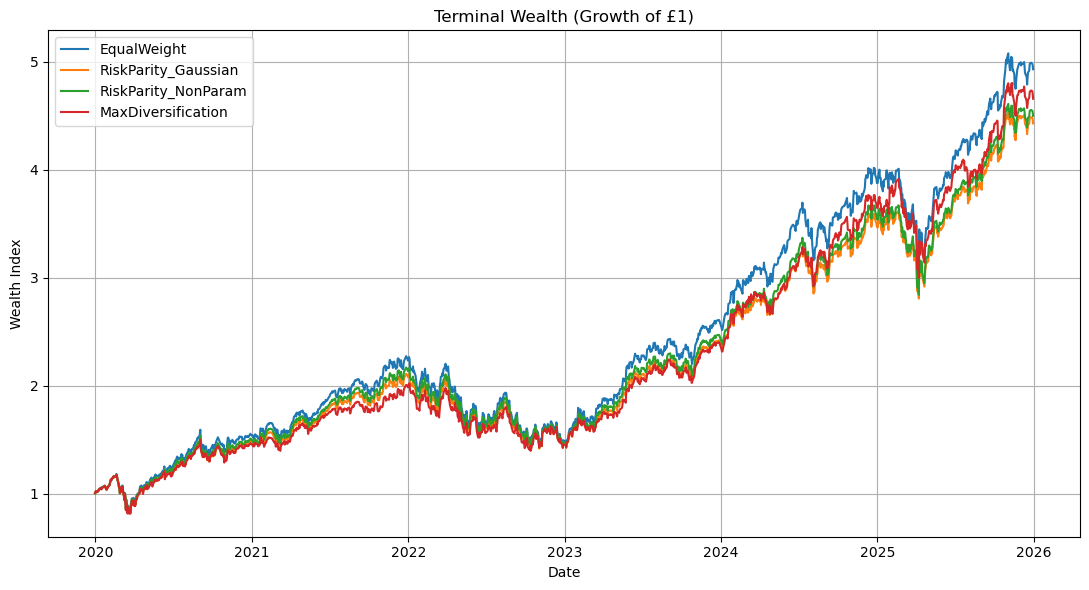

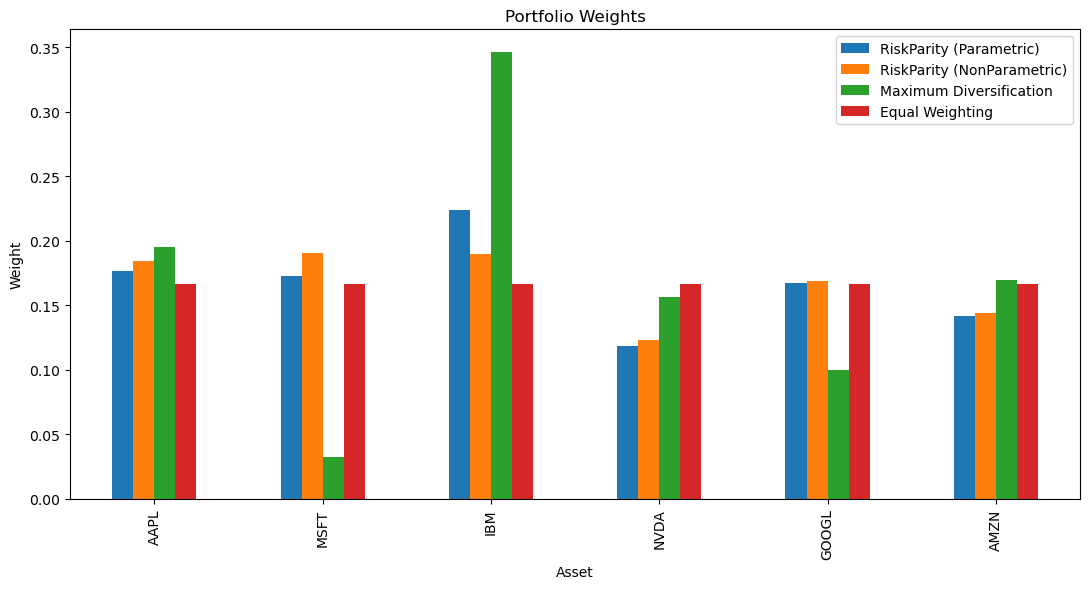

In [18]:
# Cumulative wealth
wealth_df = pd.DataFrame({
    "EqualWeight": np.exp(np.cumsum(r_eq)),
    "RiskParity_Gaussian": np.exp(np.cumsum(r_rp_g)),
    "RiskParity_NonParam": np.exp(np.cumsum(r_rp_np)),
    "MaxDiversification": np.exp(np.cumsum(r_md))
}, index=test_dates)

plt.figure(figsize=(11, 6))
for col in wealth_df.columns:
    plt.plot(wealth_df.index, wealth_df[col], label=col, linewidth=1.5)
plt.title("Terminal Wealth (Growth of £1)")
plt.xlabel("Date")
plt.ylabel("Wealth Index")
plt.legend()
plt.grid(True)
plt.tight_layout()
if save_figures:
    plt.savefig(os.path.join(img_dir, "Q3_cumulative_wealth.png"), dpi=200)
plt.show()


# Portfolio weights
table_weights.plot(kind="bar", figsize=(11, 6))
plt.title("Portfolio Weights")
plt.xlabel("Asset")
plt.ylabel("Weight")
plt.tight_layout()
if save_figures:
    plt.savefig(os.path.join(img_dir, "Q3_weights.png"), dpi=200)
plt.show()